In [1]:
suppressPackageStartupMessages({
    library(reticulate)
    library(ggplot2)
    library(scater)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(patchwork)
    library(scCustomize)
    library(future)
    plan("multiprocess", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

In [2]:
path_ref <- '/hpc/pmc_stunnenberg/cruiz/scRNA/analysis/gbm/deep_sequencing/nature_genetics/data/GBmap_core_Azimuth_NG.rds'
reference <- readRDS(path_ref)

In [3]:
dmg_atlas <- readRDS('../data/merged_dmg_atlas_filtered_no_doublets.rds')
dmg_atlas

An object of class Seurat 
103310 features across 548561 samples within 2 assays 
Active assay: RNA (51655 features, 0 variable features)
 1 other assay present: RAW

In [4]:
dmg_atlas <- subset(dmg_atlas, features = data.table::fread('../data/protein_coding_genes_dmg_atlas.csv')$genes)
dmg_atlas

An object of class Seurat 
38496 features across 548561 samples within 2 assays 
Active assay: RNA (19248 features, 0 variable features)
 1 other assay present: RAW

In [5]:
dmg <- subset(dmg_atlas, cells = read.csv('../data/dmg_atlas_3mad_200genesmin.csv') %>% 
                           pull(cell_names))
dmg

An object of class Seurat 
38496 features across 409561 samples within 2 assays 
Active assay: RNA (19248 features, 0 variable features)
 1 other assay present: RAW

In [6]:
rm(dmg_atlas)

In [7]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8794242,469.7,12952861,691.8,11639469,621.7
Vcells,6826127917,52079.3,18051702435,137723.6,17727508728,135250.2


In [8]:
dmg <- NormalizeData(dmg)%>%FindVariableFeatures()%>%ScaleData()%>%RunPCA(verbose = FALSE)%>%
        FindNeighbors(verbose = F) %>% FindClusters(verbose = F)%>%
        RunUMAP(dims = 1:15, reduction = "pca", verbose = F)

Centering and scaling data matrix

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


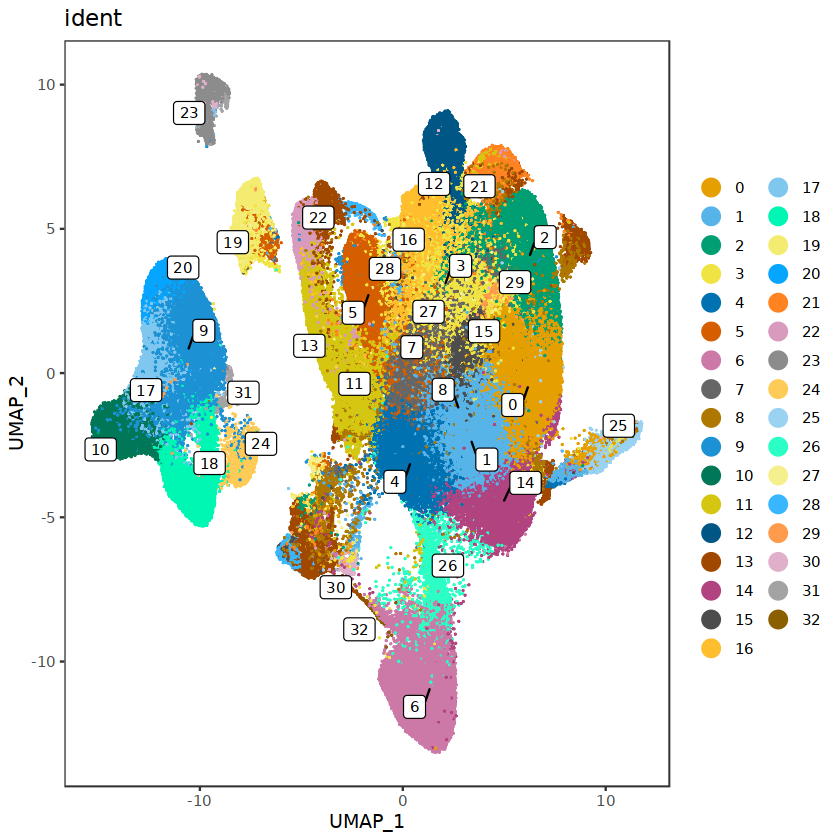

In [9]:
dittoDimPlot(dmg, do.raster = TRUE,
             reduction.use = "umap", var = "ident", 
             do.label = T, labels.size = 3, size = 0.5)

### Reference mapping

In [10]:
reference <- FindVariableFeatures(reference, selection.method = "vst", nfeatures = 2000)
reference <- ScaleData(reference, features = VariableFeatures(object = reference), verbose = FALSE)
reference <- RunPCA(reference, features = VariableFeatures(object = reference), verbose = FALSE)

In [11]:
anchors <- FindTransferAnchors(
  reference = reference,
  query = dmg,
  features = rownames(reference[["RNA"]]),
  normalization.method = "LogNormalize",
  reference.reduction = "pca",
  dims = 1:50
)

Warning message:
“311 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 4689 features.”
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 56094 anchors

Filtering anchors

	Retained 9476 anchors



`Map Query` functions run separately

In [12]:
dmg <- TransferData(
  anchorset = anchors, 
  reference = reference,
  query = dmg,
  refdata = list(
      annotation_level_1 = 'annotation_level_1',
      annotation_level_2 = 'annotation_level_2',
      annotation_level_3 = 'annotation_level_3',
      annotation_level_4 = 'annotation_level_4'
  ),
)

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from predictionscoreannotation_level_1_ to predictionscoreannotationlevel1_”
Predicting cell labels

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from predictionscoreannotation_level_2_ to predictionscoreannotationlevel2_”
Predicting cell labels

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from predictionscoreannotation_level_3_ to predictionscoreannotationlevel3_”
Predicting cell labels

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from predictionscoreannotation_level_4_ to predictionscoreannotationlevel4_”


In [13]:
dmg <- IntegrateEmbeddings(
  anchorset = anchors,
  reference = reference,
  query = dmg, 
  new.reduction.name = "ref.pca"
)


Integrating dataset 2 with reference dataset

Finding integration vectors

Integrating data



### UMAP embbeding projection

In [14]:
dmg <- ProjectUMAP(
  query = dmg, 
  query.reduction = "ref.pca", 
  reference = reference, 
  reference.reduction = "pca", 
  reduction.model = "umap"
)

Computing nearest neighbors

Running UMAP projection

11:35:38 Read 409561 rows

11:35:38 Processing block 1 of 1

11:35:39 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:35:46 Initializing by weighted average of neighbor coordinates using 1 thread

11:35:47 Commencing optimization for 67 epochs, with 12286830 positive edges

11:39:59 Finished



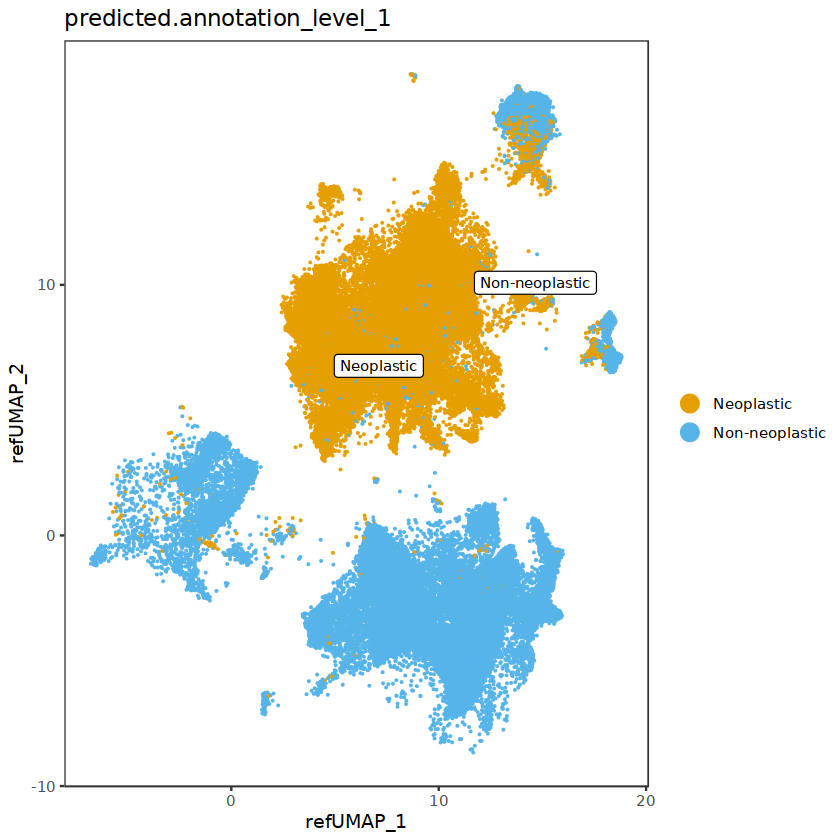

In [15]:
dittoDimPlot(dmg, 
             reduction.use = "ref.umap", var = "predicted.annotation_level_1", 
             do.label = T, labels.size = 3, size = 0.5)

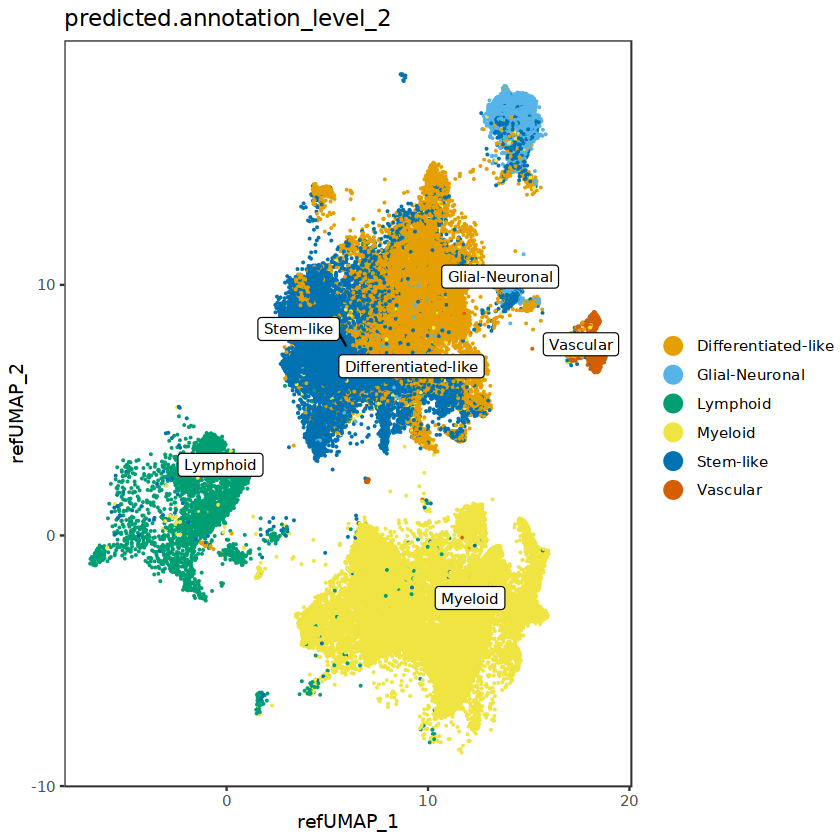

In [16]:
dittoDimPlot(dmg, 
             reduction.use = "ref.umap", var = "predicted.annotation_level_2", 
             do.label = T, labels.size = 3, size = 0.5)

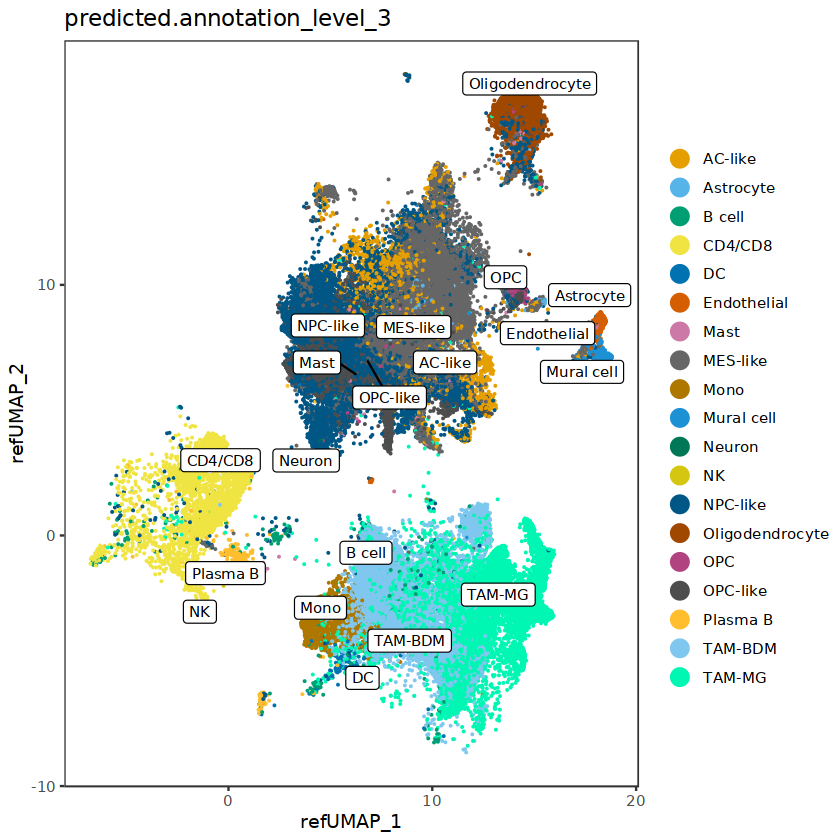

In [17]:
dittoDimPlot(dmg, 
             reduction.use = "ref.umap", var = "predicted.annotation_level_3", 
             do.label = T, labels.size = 3, size = 0.5)

Warning message:
“ggrepel: 28 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


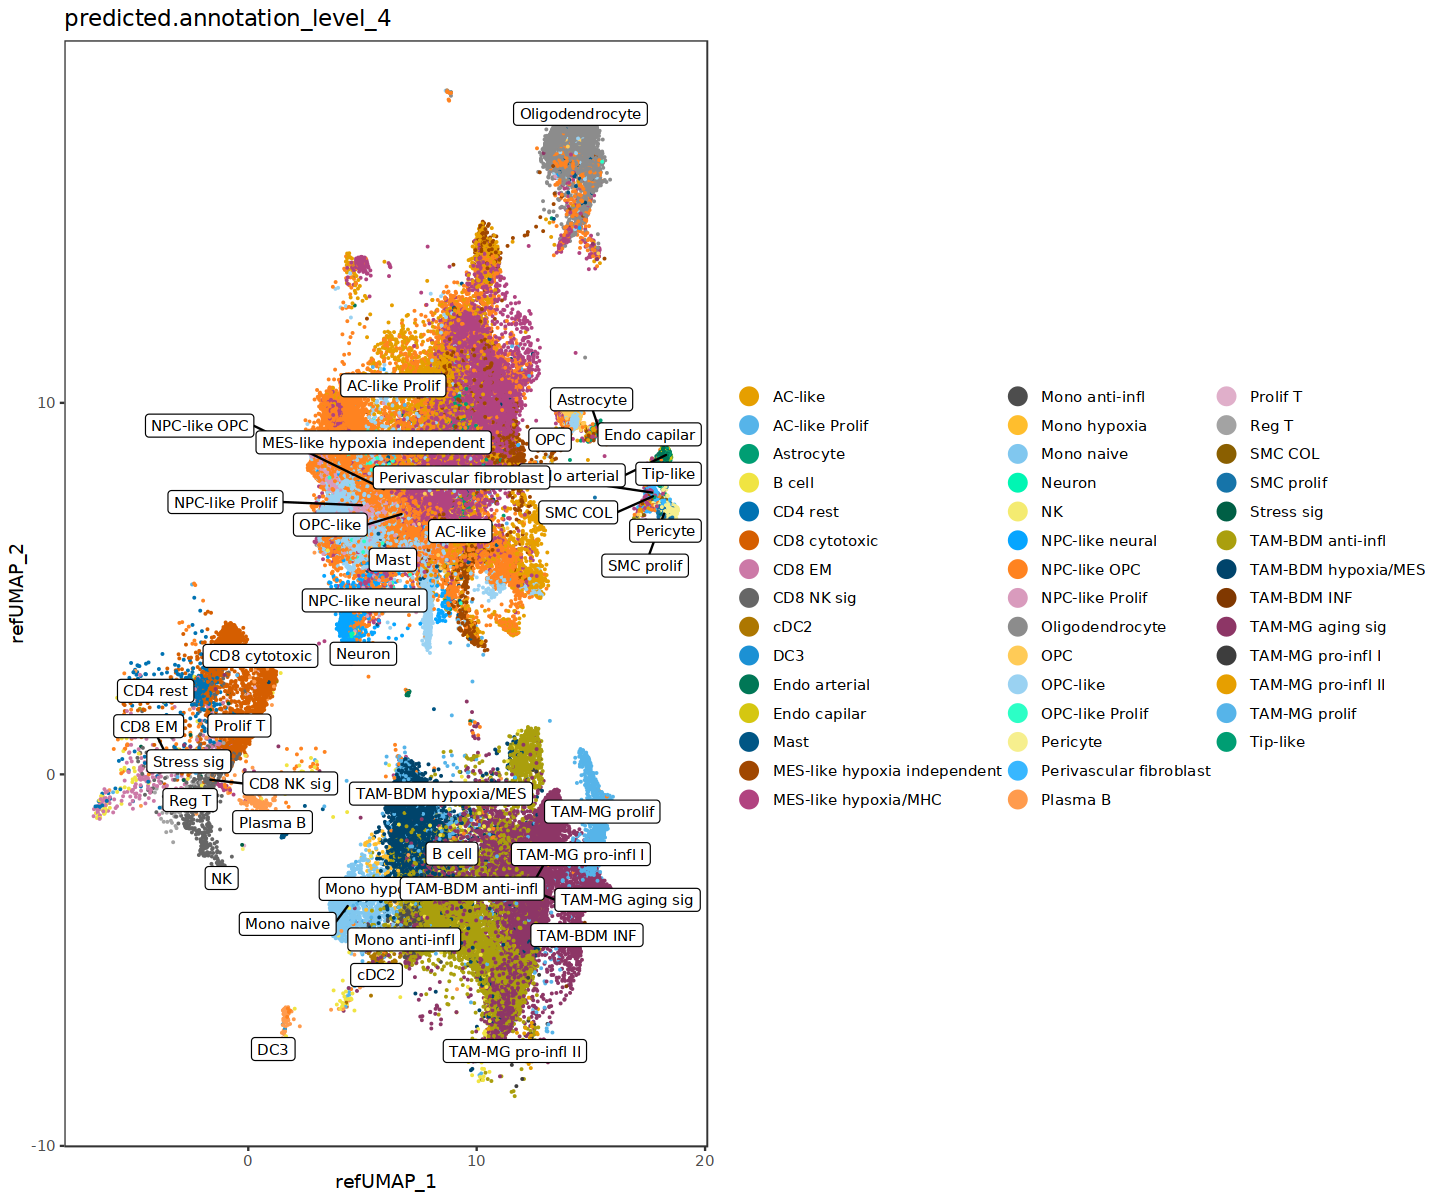

In [18]:
options(repr.plot.height = 10, repr.plot.width = 12)
dittoDimPlot(dmg, 
             reduction.use = "ref.umap", var = "predicted.annotation_level_4", 
             do.label = T, labels.size = 3, size = 0.5)

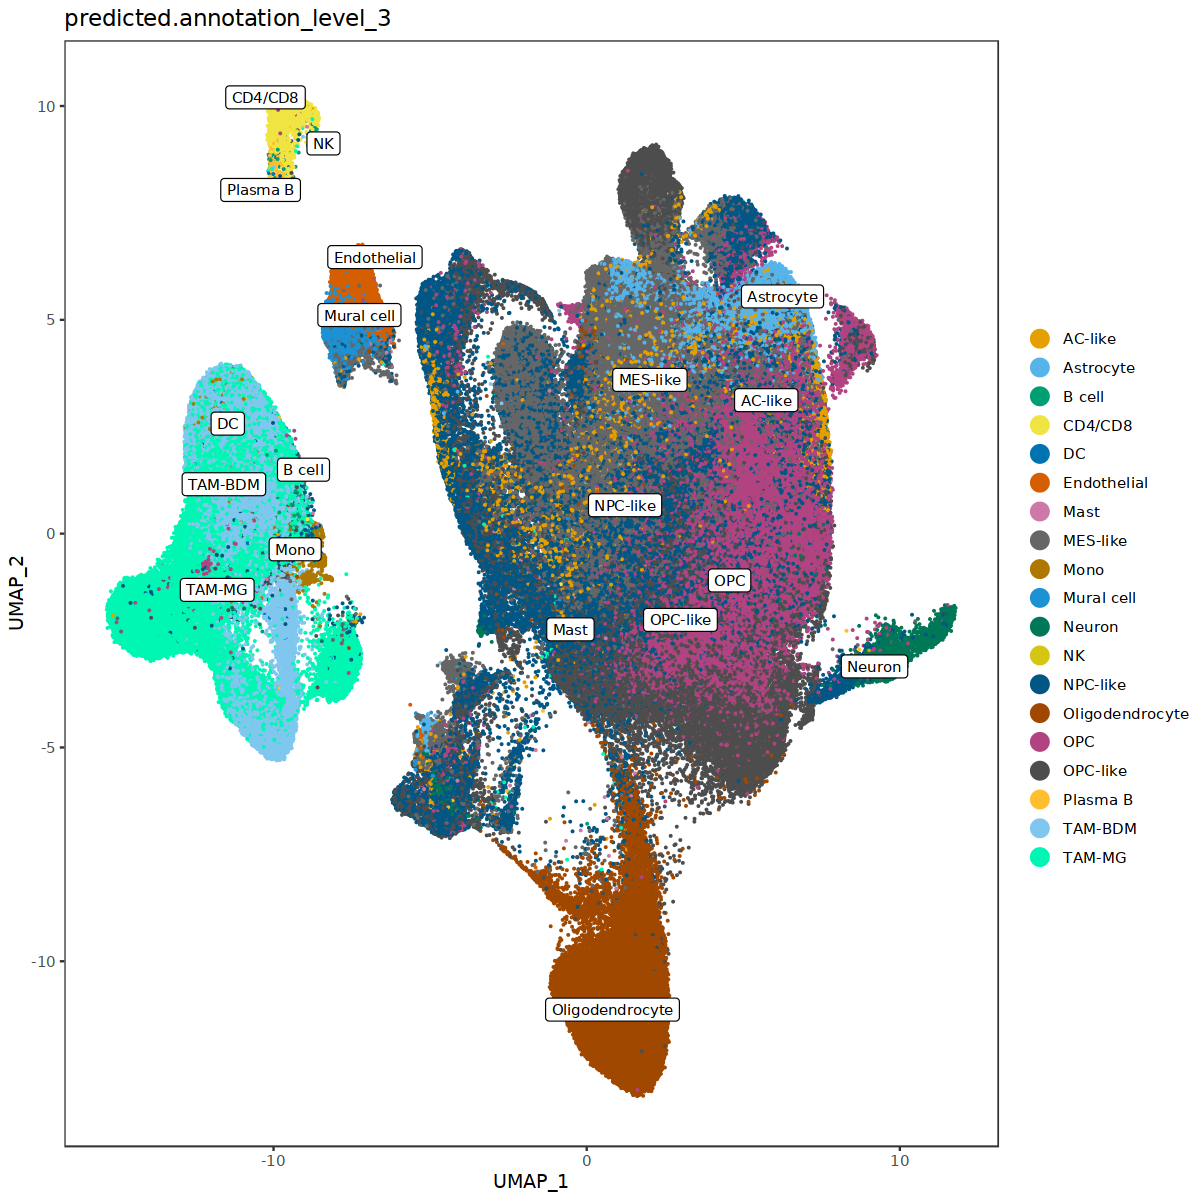

In [19]:
options(repr.plot.height = 10, repr.plot.width = 10)
dittoDimPlot(dmg, 
             reduction.use = "umap", var = "predicted.annotation_level_3", 
             do.label = T, labels.size = 3, size = 0.5)

In [20]:
saveRDS(dmg, '../data/merged_dmg_atlas_qc_filtered.rds')

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



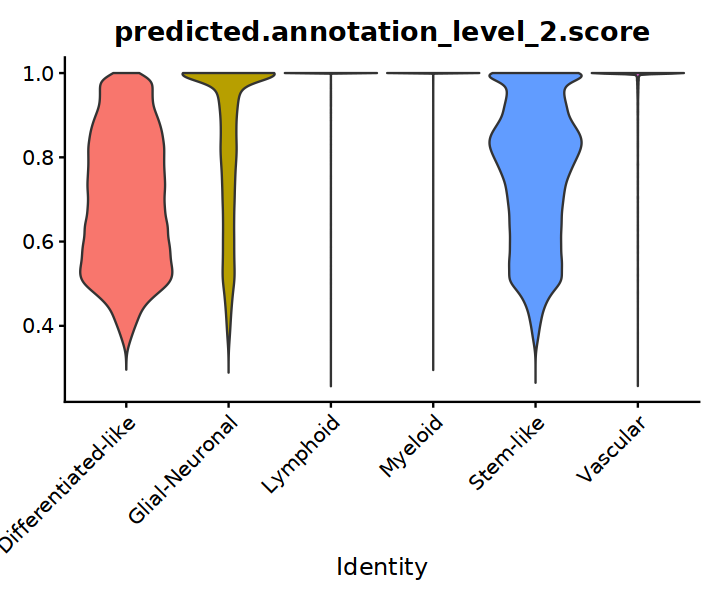

In [25]:
options(repr.plot.height = 5, repr.plot.width = 6)
VlnPlot(dmg, features = "predicted.annotation_level_2.score", pt.size = 0,
        group.by = 'predicted.annotation_level_2') + NoLegend()

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



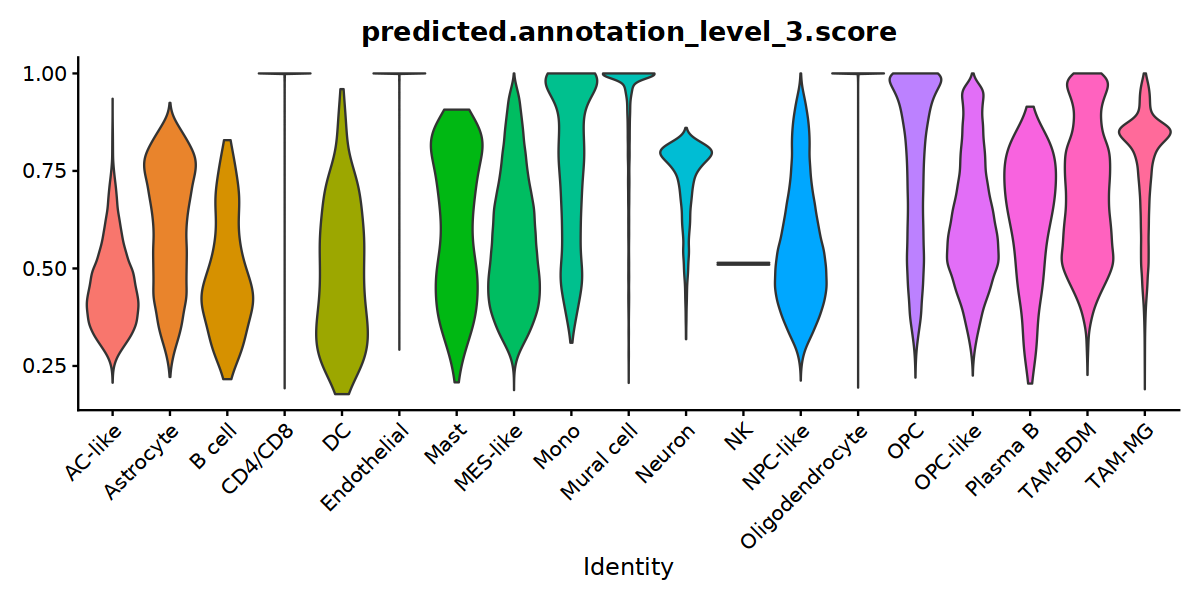

In [21]:
options(repr.plot.height = 5, repr.plot.width = 10)
VlnPlot(dmg, features = "predicted.annotation_level_3.score", pt.size = 0,
        group.by = 'predicted.annotation_level_3') + NoLegend()

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Groups with fewer than two data points have been dropped.”


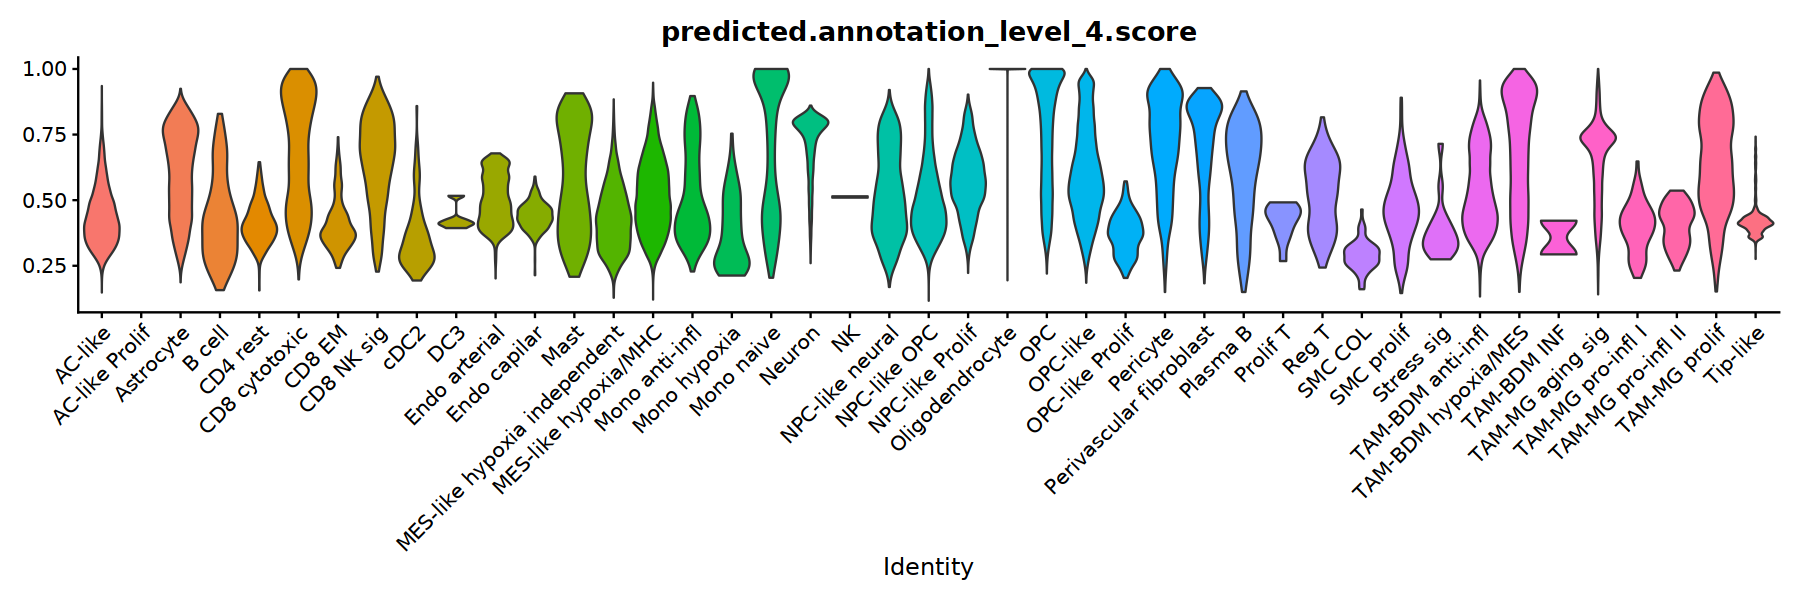

In [22]:
options(repr.plot.height = 5, repr.plot.width = 15)
VlnPlot(dmg, features = "predicted.annotation_level_4.score", pt.size = 0,
        group.by = 'predicted.annotation_level_4') + NoLegend()

In [34]:
# Set the identities correctly.
Idents(dmg) <- dmg$predicted.annotation_level_3

n_cells <- nrow(dmg@meta.data)
n_sample <- round(n_cells * 0.3)
sampled_cells <- sample(Cells(dmg), n_sample)
# Compute DE genes and transform to a tibble.
de_genes <- tibble::tibble(FindAllMarkers(object = subset(dmg, cells = sampled_cells),
                                          min.pct = 0.25, 
                                          only.pos = TRUE))

Calculating cluster NPC-like

Calculating cluster OPC

Calculating cluster OPC-like

Calculating cluster Endothelial

Calculating cluster TAM-BDM

Calculating cluster Mono

Calculating cluster CD4/CD8

Calculating cluster MES-like

Calculating cluster TAM-MG

Calculating cluster B cell

Calculating cluster DC

Calculating cluster Mural cell

Calculating cluster Plasma B

Calculating cluster AC-like

Calculating cluster Neuron

Calculating cluster Mast

Calculating cluster Astrocyte



In [45]:
top5_markers <- Extract_Top_Markers(marker_dataframe = de_genes, num_genes = 5, named_vector = FALSE,
    make_unique = TRUE)

In [44]:
options(repr.plot.height = 20, repr.plot.width = 50)

dmg$EGFR <- NULL
# Add more layers of mean expression with group.by.
p <- SCpubr::do_GroupwiseDEPlot(sample = dmg,
                                de_genes = de_genes,
                               min.cutoff = 1)

p

ERROR: Error in grid.Call.graphics(C_downvppath, name$path, name$name, strict): Viewport '-log10(Adjusted P-value)_heatmap_body_1_1' was not found


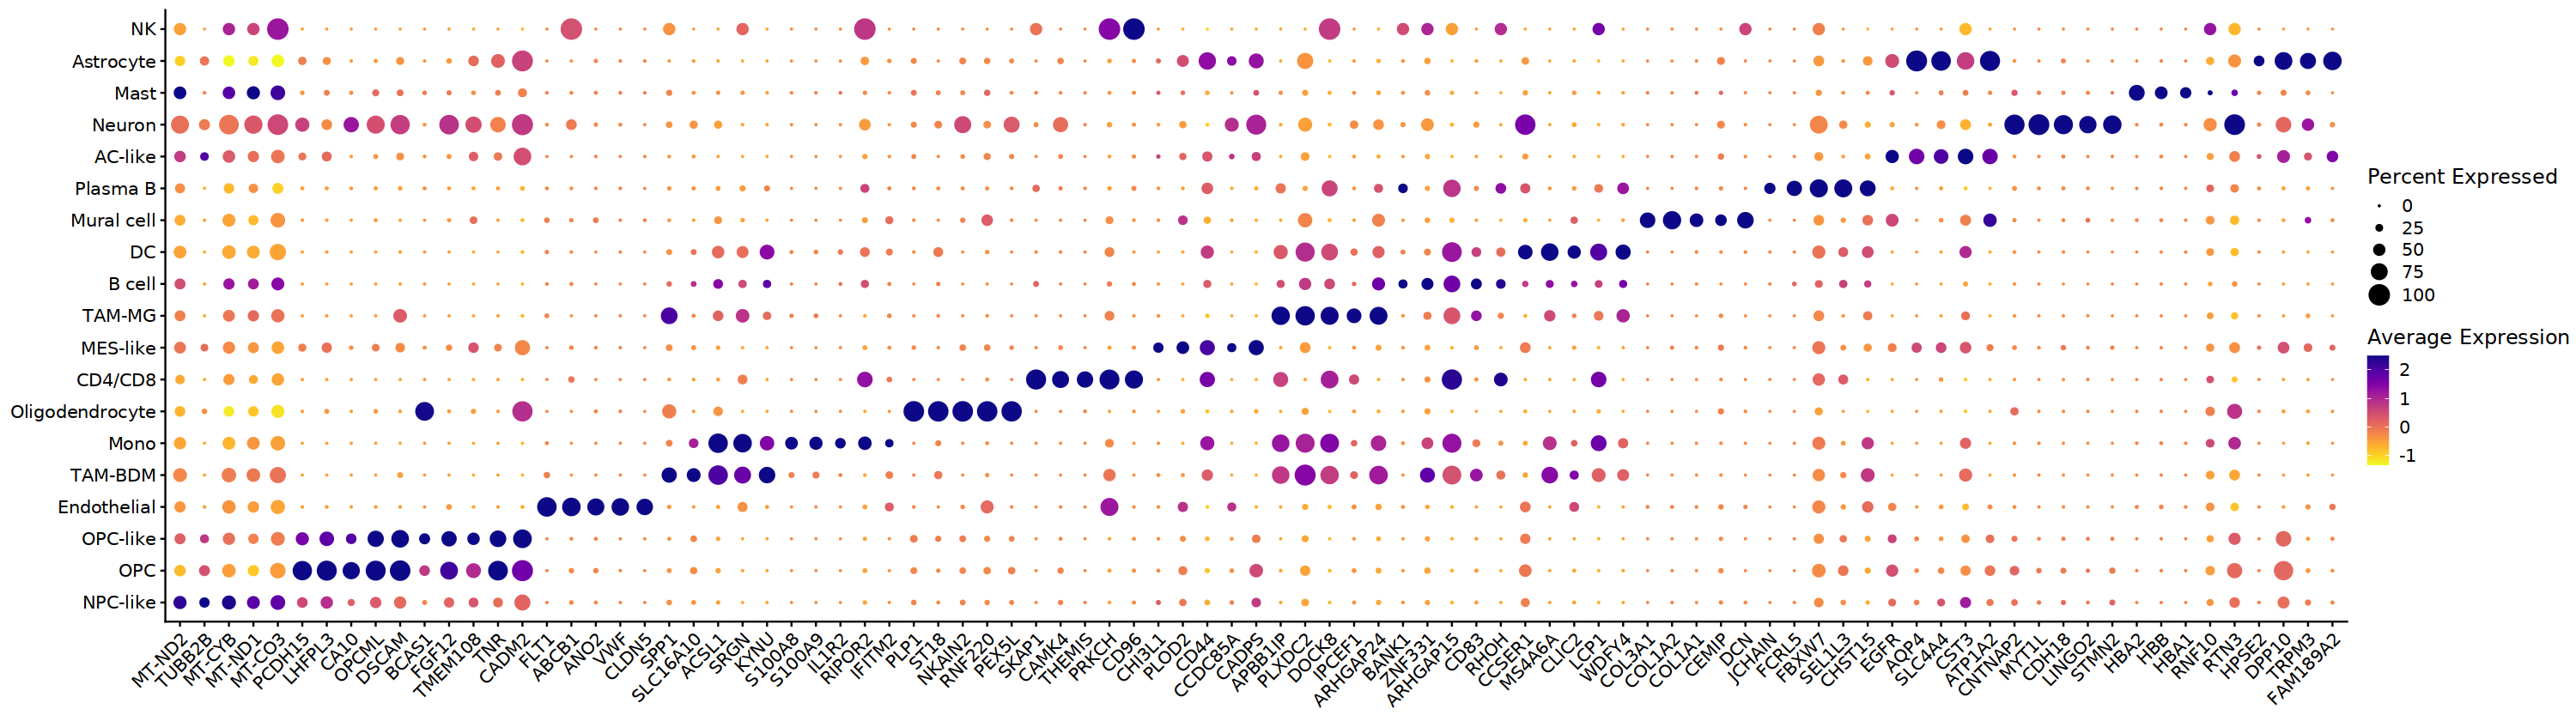

In [46]:
options(repr.plot.height = 7, repr.plot.width = 25)
DotPlot_scCustom(seurat_object = dmg, features =  top5_markers, x_lab_rotate = TRUE,
                 colors_use = viridis_plasma_dark_high)

In [47]:
saveRDS(de_genes, '../data/merged_dmg_atlas_qc_filtered_de_genes.rds')